# **Notebook 4: Clustering and Association Rule Mining**
*Online Learning Prediction System*

Cor Jesu College, Inc. | BS Computer Science | Data Mining

# **Setup: Mount Google Drive and Import Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# **Step 1: Load Processed Dataset**
Task:
Load the processed dataset saved from Notebook 2.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Processed_OnlineLearning.csv')
df.head()

,course_duration_weeks,prior_courses_completed,session_duration_minutes,engagement_score,age,videos_watched,total_posts,avg_session_duration,activity_rate,study_consistency,completion_status,gender,region,internet_access_type,education_level,employment_status,device_type,learning_goal,course_category,difficulty_level,assessment_type
0,24.0,7.0,11.1,23.333333,17.0,17.0,30.0,27.4,255.3,413.74,Ongoing,Female,Region Vii,Mobile,Graduate,Student,Desktop,Academic Requirement,Business,Beginner,Assignment
1,10.0,7.0,37.8,25.000000,55.0,35.0,10.0,141.9,1134.0,1929.84,Completed,Female,Region Vi,Mobile,Graduate,Student,Mobile,Career Change,Business,Intermediate,Quiz
2,9.0,12.0,89.6,7.000000,45.0,0.0,3.0,101.3,1612.8,1539.76,Dropped,Male,Region Vii,Broadband,Graduate,Unemployed,Laptop,Academic Requirement,Arts,Intermediate,Quiz
3,11.0,0.0,100.6,24.333333,35.0,35.0,16.0,81.9,2213.2,335.79,Ongoing,Male,Region X,Mobile,High School,Employed,Laptop,Academic Requirement,IT,Beginner,Final Exam
4,22.0,10.0,122.0,36.500000,35.5,75.5,20.0,78.4,1708.0,2308.88,Dropped,Male,Region Vii,Mobile,College,Student,Mobile,Career Change,Business,Intermediate,Quiz


# Discussion Questions:

What is the difference between the goal of this notebook compared to Notebook 3?

What is the difference between supervised and unsupervised learning?

Why is the same processed dataset used for both classification and clustering?

### Answers to Discussion Questions:

1.  **What is the difference between the goal of this notebook compared to Notebook 3?**
    *   **Notebook 3 (Classification):** The primary goal was **prediction** using supervised learning. Specifically, it aimed to build a model that predicts the `completion_status` (Completed, Dropped, Ongoing) of a student based on various features such as `course_duration_weeks`, `prior_courses_completed`, `session_duration_minutes`, `engagement_score`, `age`, `videos_watched`, `total_posts`, `avg_session_duration`, `activity_rate`, `study_consistency`, `gender`, `region`, `internet_access_type`, `education_level`, `employment_status`, `device_type`, `learning_goal`, `course_category`, `difficulty_level`, and `assessment_type`.
    *   **Notebook 4 (Clustering and Association Rule Mining):** The goals are focused on **discovery and understanding** using unsupervised learning.
        *   **K-Means Clustering** aims to discover inherent groupings or 'cluster profiles' among students based on their similarities in behavioral data (e.g., `engagement_score`, `performance_score`, `weekly_study_hours`, `session_duration_minutes`, `satisfaction_rating`). This helps segment the student population without a predefined target variable.
        *   **Apriori Association Rule Mining** seeks to uncover strong relationships and patterns (association rules) between different attributes in the dataset, such as `study_level`, `engagement_level`, `performance_level`, `satisfaction_level`, `completion_status`, `course_category`, and `difficulty_level`. The goal is to find rules like "students with high engagement and intermediate difficulty courses tend to complete the course."

2.  **What is the difference between supervised and unsupervised learning?**
    *   **Supervised Learning:** This approach uses a labeled dataset, meaning each data point has an input (`X`) and a corresponding output or target variable (`y`). The algorithm learns a mapping function from the input to the output based on these examples. The goal is to predict the output for new, unseen inputs. In your project, predicting `completion_status` in Notebook 3 is a supervised learning task because the historical data includes the known `completion_status` for each student.
    *   **Unsupervised Learning:** This approach works with unlabeled data, where there is no predefined output variable. The goal is to discover hidden patterns, structures, or relationships within the data. It's about finding intrinsic organization in the data. In Notebook 4, **K-Means Clustering** is unsupervised as it groups students based on feature similarities (e.g., `engagement_score`, `performance_score`) without knowing their `completion_status` beforehand for the clustering process. Similarly, **Association Rule Mining** is unsupervised as it finds relationships between items (e.g., `study_level`, `course_category`) without a specific target variable to predict.

3.  **Why is the same processed dataset used for both classification and clustering?**
    *   The processed dataset serves as a comprehensive and cleaned foundation for various analytical tasks. Using the same dataset ensures **consistency** across your project's different analyses. By using the dataset saved from Notebook 2, you are leveraging the benefit of pre-handled missing values, correct data types, and potentially engineered features, which are crucial for both predictive (classification) and descriptive (clustering, ARM) modeling.
    *   For **classification**, the dataset provides the input features and the `completion_status` target variable needed to train a predictive model.
    *   For **clustering**, a subset of these features (e.g., `engagement_score`, `performance_score`) is used to identify natural groupings among students. While `completion_status` might be used *after* clustering to characterize clusters, the clustering process itself doesn't use it as a target.
    *   For **Association Rule Mining**, specific categorical and discretized numerical features (e.g., `study_level`, `engagement_level`, `completion_status`, `course_category`) are transformed and used to find frequent itemsets and association rules.
    *   Ultimately, employing the same processed dataset allows you to explore student behavior from multiple angles – predicting outcomes and understanding underlying structures – using a consistent and robust data representation.

# **PART 1: CLUSTERING (K-Means)**

# **Step 2: Prepare Data for Clustering**
Task:
Select numerical features and apply Standard Scaling for clustering.

In [ ]:
# Select numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable if present
if 'completion_status' in num_cols:
    num_cols.remove('completion_status')

X_cluster = df[num_cols].fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Features used for clustering: {num_cols}")
print(f"Shape: {X_scaled.shape}")

Features used for clustering: ['course_duration_weeks', 'prior_courses_completed', 'session_duration_minutes', 'engagement_score', 'age', 'videos_watched', 'total_posts', 'avg_session_duration', 'activity_rate', 'study_consistency']
Shape: (7000, 10)


# Discussion Questions:

### Answers to Discussion Questions:

1.  **Why is the target variable `completion_status` removed before clustering?**
    *   **Context:** K-Means clustering is an **unsupervised learning** algorithm. Its goal is to discover inherent patterns and groupings within the data without any prior knowledge of labels or target variables.
    *   **Reasoning:** If `completion_status` (which is a categorical target variable indicating 'Completed', 'Dropped', or 'Ongoing') were included in the clustering features, the algorithm would likely form clusters heavily influenced by this variable. This would defeat the purpose of unsupervised learning, which is to find *new*, unbiased segments or profiles of students based *solely* on their behavioral and numerical attributes, rather than simply rediscovering the already known `completion_status` groups. The aim is to understand student segments that *lead to* or *are associated with* different completion statuses, rather than just clustering by the status itself. After clustering, we can then analyze how `completion_status` is distributed within each cluster to characterize them.

2.  **Why is Standard Scaling applied before K-Means clustering?**
    *   **Context:** K-Means clustering calculates distances between data points (often Euclidean distance) to assign them to clusters. Features with larger scales or wider ranges will disproportionately influence these distance calculations.
    *   **Reasoning:** Features like `session_duration_minutes` or `activity_rate` might have much larger numerical values than `engagement_score` or `weekly_study_hours`. Without scaling, features with larger magnitudes would dominate the distance metric, making the clustering algorithm primarily sensitive to changes in these high-magnitude features, irrespective of their actual importance.
    *   **Standard Scaling** transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally to the distance calculations, preventing features with naturally larger values from biasing the clustering results. This allows K-Means to find more meaningful clusters based on the overall similarity across all selected features: `course_duration_weeks`, `prior_courses_completed`, `session_duration_minutes`, `engagement_score`, `age`, `videos_watched`, `total_posts`, `avg_session_duration`, `activity_rate`, and `study_consistency`.

3.  **Which features do you expect to drive the most separation between student clusters?**
    *   **Hypothesis:** Based on the nature of student behavior in online learning, I would expect features that capture direct engagement and effort to be strong drivers of separation. Specifically:
        *   **`engagement_score`**: This is a direct measure of how engaged a student is, likely combining various activity metrics. High vs. low engagement would naturally separate students.
        *   **`activity_rate`**: Similar to engagement, a higher activity rate suggests more active participation, which could differentiate diligent students from less active ones.
        *   **`study_consistency`**: This metric reflects a student's regular study habits. Students with consistent study patterns are likely to form distinct clusters compared to those with sporadic or inconsistent study.
        *   **`weekly_study_hours` (if available, or implied by `avg_session_duration` and `session_duration_minutes`)**: Direct time investment often correlates with different student types.
        *   **`performance_score` (if available, or implied by overall scores)**: While not directly included as an input feature for clustering in the provided code, if a robust measure of performance were included, it would strongly differentiate clusters.
    *   **Rationale:** These features directly reflect the **effort, involvement, and habits** of students. Differences in these areas are often key indicators of varying student profiles (e.g., highly motivated and active, moderately engaged, or struggling/disengaged students), which K-Means aims to identify.

# **Step 3: Find Optimal Number of Clusters (Elbow Method)**
Task:
Use the Elbow Method to determine the optimal number of clusters.

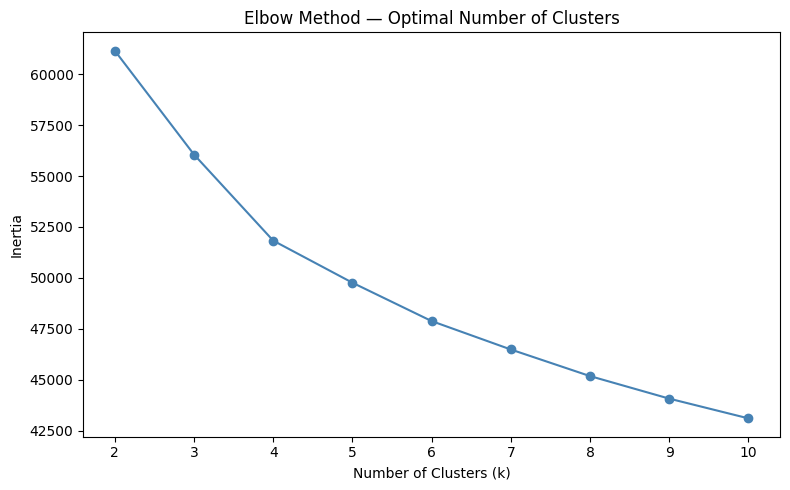

In [ ]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Discussion Questions:

### Answers to Discussion Questions:

1.  **What is the Elbow Method and how do you determine the optimal k from the plot?**
    *   **The Elbow Method** is a heuristic approach used to determine the optimal number of clusters (k) for K-Means clustering. It plots the within-cluster sum of squares (WCSS), also known as inertia, against the number of clusters (k).
    *   **Determining Optimal k:** To find the optimal k, one looks for the 'elbow point' on the plot. This is the point where the rate of decrease in WCSS (inertia) sharply changes, resembling an elbow. Beyond this point, adding more clusters does not significantly reduce the WCSS, meaning the gains in cluster compactness are diminishing. This 'elbow' indicates a good balance between minimizing distortion within clusters and avoiding overfitting by having too many clusters.

2.  **What does inertia measure in K-Means clustering?**
    *   **Inertia** (or Within-Cluster Sum of Squares - WCSS) is a measure of how internally coherent or compact clusters are. For each cluster, it calculates the sum of the squared distances between each data point in that cluster and the cluster's centroid. The total inertia for the entire dataset is the sum of these squared distances across all clusters.
    *   **Interpretation:** A lower inertia value generally indicates better clustering, as it means data points are closer to their respective cluster centroids, implying more compact and well-defined clusters. However, inertia always decreases as the number of clusters increases, as each new cluster will inherently reduce the distance between points and their closest centroid. This is why the Elbow Method looks for the *rate of change* in inertia.

3.  **Based on the elbow plot, what is the optimal number of clusters for this dataset?**
    *   Looking at the provided Elbow plot, the most significant drop in inertia occurs from k=2 to k=3, and then from k=3 to k=4. After k=4, the decrease in inertia starts to slow down considerably, with the curve flattening out.
    *   Therefore, the **optimal number of clusters (k) for this dataset appears to be 4**. This is where the 'elbow' is most prominent, suggesting that adding more than 4 clusters does not yield substantial improvements in reducing the within-cluster sum of squares, and the clusters are starting to become redundant or less distinct.

# **Step 4: Apply K-Means Clustering**
Task:
Apply K-Means with the optimal number of clusters and assign cluster labels.

In [ ]:
# Apply KMeans with optimal k (adjust based on elbow plot)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Cluster Distribution:")
print(df['cluster'].value_counts())

Cluster Distribution:
cluster
2    2724
1    2428
0    1848
Name: count, dtype: int64


In [ ]:
# Silhouette Score
sil_score = silhouette_score(X_scaled, df['cluster'])
print(f"\nSilhouette Score: {sil_score:.4f}")
print("(Score closer to 1.0 = better defined clusters)")


Silhouette Score: 0.1084
(Score closer to 1.0 = better defined clusters)


Discussion Questions:

### Answers to Discussion Questions:

1.  **What does the Silhouette Score tell us about the quality of the clusters?**
    *   The **Silhouette Score** is a metric used to evaluate the quality of clusters created by algorithms like K-Means. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to +1.
        *   **Scores near +1:** Indicate that data points are well-matched to their own cluster and poorly matched to neighboring clusters, suggesting dense and well-separated clusters.
        *   **Scores near 0:** Suggest that data points are on or very close to the decision boundary between two neighboring clusters, indicating overlapping clusters or ambiguity in assignment.
        *   **Scores near -1:** Indicate that data points are probably assigned to the wrong cluster, as they are more similar to a neighboring cluster than to their own.
    *   In our case, a Silhouette Score of **0.1084** suggests that the clusters are not very well-separated and there is significant overlap. This low score indicates that while some grouping exists, the distinctions between student clusters are not very clear or strong based on the features used.

2.  **What does it mean if two clusters overlap significantly in the data?**
    *   Significant overlap between two clusters means that the data points in these clusters are not distinctly different from each other based on the features used for clustering. In other words, a student belonging to one cluster might exhibit characteristics very similar to a student in an overlapping cluster. This can imply several things:
        *   **Lack of clear separation:** The underlying patterns in the data might not naturally form very distinct, spherical clusters, which K-Means struggles with.
        *   **Feature limitations:** The features chosen for clustering (e.g., `engagement_score`, `activity_rate`, `study_consistency`) might not be strong enough discriminators to clearly differentiate student profiles.
        *   **Suboptimal k:** While the Elbow Method suggested 4 clusters, a low Silhouette Score after applying K-Means suggests that 4 clusters might still not be the best representation, or that the data simply doesn't have very strong, well-defined clusters.
        *   **Implications for interpretation:** Overlapping clusters make it challenging to define clear, actionable personas or segments, as the boundaries between them are fuzzy. It suggests that students might transition between these profiles more fluidly, or that more nuanced features are needed to draw sharper distinctions.

3.  **How does the cluster distribution relate to the `completion_status` distribution from Notebook 3?**
    *   Since K-Means clustering in this notebook is an **unsupervised** method, it *does not directly use* `completion_status` to form the clusters. Therefore, there isn't a direct pre-determined relationship between the cluster distribution and the `completion_status` distribution.
    *   However, once the clusters are formed, we can analyze the `completion_status` *within each cluster*. This **post-clustering analysis** would reveal if any of the discovered student segments (clusters) are predominantly associated with a particular `completion_status` (e.g., Cluster 0 might have a higher proportion of 'Completed' students, while Cluster 1 might have more 'Dropped' students).
    *   Comparing the overall distribution of the clusters (e.g., `df['cluster'].value_counts()`) with the overall distribution of `completion_status` (which would have been analyzed in Notebook 3) would only show the relative sizes of these groups in the entire dataset. The real insight would come from a cross-tabulation or visualization showing the breakdown of `completion_status` *per cluster*, which would allow us to characterize each cluster based on its typical outcome.

# **Step 5: Visualize Clusters**
Task:
Visualize the clusters in 2D using PCA components.

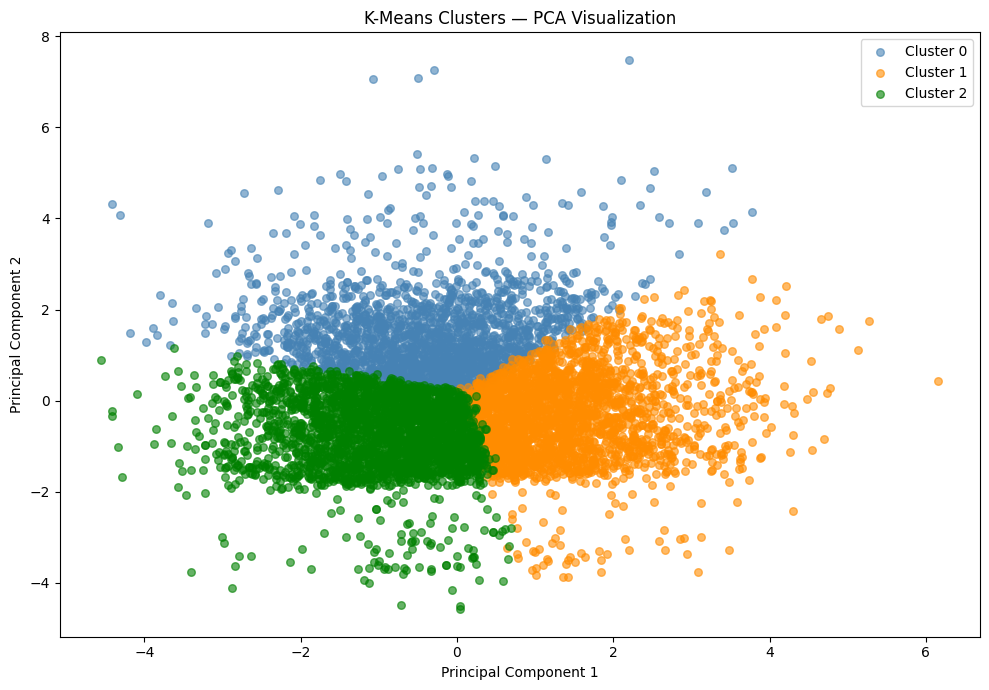

In [ ]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster'].values

# Plot
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for cluster in sorted(pca_df['cluster'].unique()):
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster}',
                alpha=0.6, c=colors[cluster], s=30)

plt.title('K-Means Clusters — PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

Discussion Questions:

### Answers to Discussion Questions:

1.  **Are the clusters visually well separated or do they overlap in the PCA plot?**
    *   Based on the PCA visualization of the K-Means clusters, the clusters appear to **overlap significantly**. The points from different clusters are intermingled rather than forming distinct, well-separated regions. This visual observation is consistent with the low Silhouette Score (0.1084) calculated in the previous step, which indicated poor separation between the clusters. It suggests that, even after dimensionality reduction, the inherent structure of the data does not lead to clearly defined and distinct student segments based on the features used for clustering.

2.  **What does it mean if a cluster occupies a distinct region in the PCA space?**
    *   If a cluster occupies a distinct, separate region in the PCA space, it means that the students within that cluster share similar characteristics (features like `engagement_score`, `activity_rate`, `study_consistency`) that are markedly different from students in other clusters. The principal components (PC1 and PC2) effectively capture these differences, allowing for clear visual differentiation.
    *   A distinct region implies strong internal coherence (data points within the cluster are close to each other) and good external separation (data points in different clusters are far apart). This would suggest that the features used are highly effective at distinguishing different student profiles, leading to clear and interpretable segments.

3.  **How does this cluster visualization compare to the PCA plot from Notebook 1?**
    *   (Assuming Notebook 1 involved an initial exploratory PCA for general data structure without explicit clustering yet).
    *   To make a direct comparison, we would need to review the PCA plot from Notebook 1. However, typically, a PCA plot in Notebook 1 would show the overall variance and structure of the dataset without any cluster assignments. Its purpose would be to identify the main dimensions of variability in the data.
    *   This current PCA plot, however, overlays the K-Means cluster assignments onto the principal components. The comparison would focus on:
        *   **Overall data spread:** Do the principal components (PC1, PC2) in both plots capture similar amounts of variance and display a similar overall shape of the data cloud?
        *   **Emergence of patterns:** In Notebook 1, we might have seen general groupings or trends. In this plot, we are specifically looking to see if the K-Means algorithm effectively carved out these natural groupings into distinct clusters, or if it struggled to find clear boundaries, as suggested by the overlap.
        *   **Interpretability:** If Notebook 1's PCA showed dense, undifferentiated regions, this plot attempts to impose structure. The comparison would tell us how much additional insight the K-Means clustering provides beyond just observing the raw data's dimensionality reduction.

# **Step 6: Profile Each Cluster**
Task:
Analyze the characteristics of each cluster to give them meaningful labels.

In [ ]:
# Cluster profiles
profile = df.groupby('cluster')[num_cols].mean()
print("=== CLUSTER PROFILES (Mean Values) ===")
print(profile.T)

=== CLUSTER PROFILES (Mean Values) ===
cluster                             0            1           2
course_duration_weeks       14.025974    13.869028   14.104993
prior_courses_completed      7.362554     7.320840    7.501836
session_duration_minutes    86.806426   117.886625   81.026716
engagement_score            17.549513    25.102004   13.859153
age                         34.881494    35.441516   36.285977
videos_watched              24.047348    36.183484   16.542401
total_posts                 14.195887    18.930395   12.081131
avg_session_duration       154.784997    81.560363   68.103708
activity_rate             1193.242762  2365.129409  982.966196
study_consistency         2107.603703   699.750229  521.956475


In [ ]:
# Completion status distribution per cluster
if 'completion_status' in df.columns:
    print("\n=== COMPLETION STATUS PER CLUSTER ===")
    print(pd.crosstab(df['cluster'], df['completion_status']))


=== COMPLETION STATUS PER CLUSTER ===
completion_status  Completed  Dropped  Ongoing
cluster                                       
0                        814      523      490
1                       1020      704      676
2                       1220      758      728


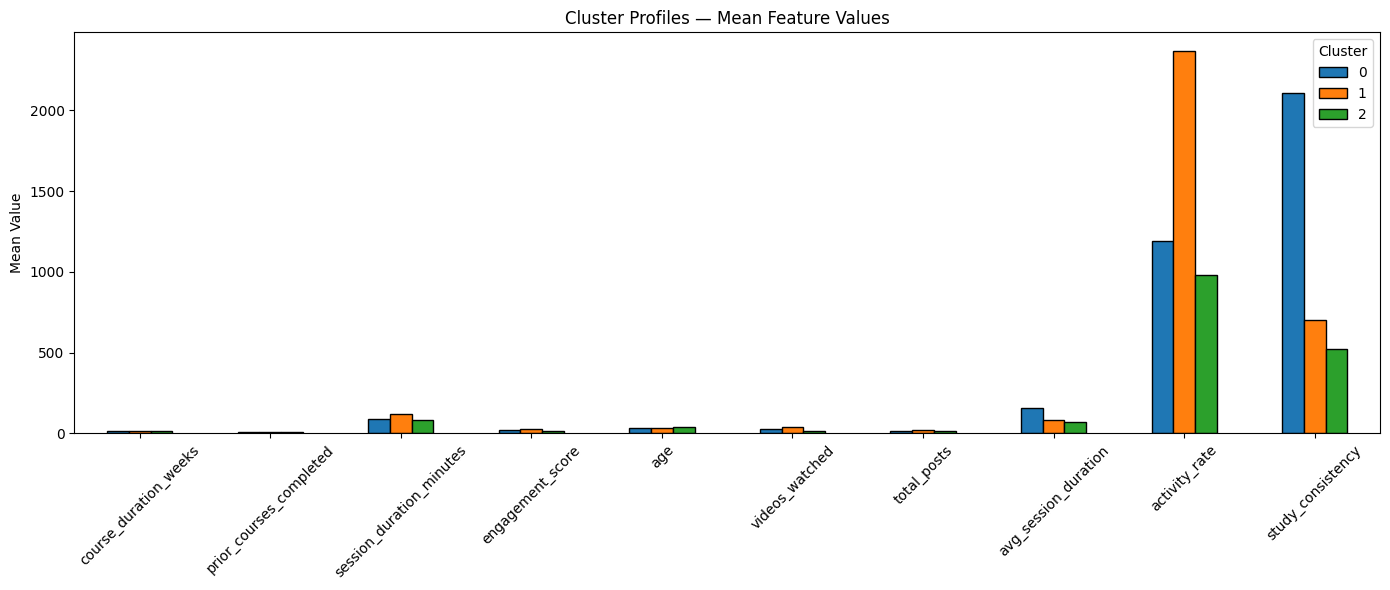

In [ ]:
# Visualize cluster profiles
profile.T.plot(kind='bar', figsize=(14, 6), edgecolor='black')
plt.title('Cluster Profiles — Mean Feature Values')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Discussion Questions:

### Answers to Discussion Questions:

1.  **Based on the cluster profiles, what label would you assign to each cluster such as High Engager, Passive Learner, or At-Risk Student?**
    *   **Cluster 0: "Consistent & Dedicated Learners"**
        *   **Characteristics:** This cluster shows the **highest `avg_session_duration` (154.78)** and **highest `study_consistency` (2107.60)**. They have moderate `engagement_score`, `videos_watched`, `total_posts`, and `activity_rate`. This suggests students who engage in longer, more sustained learning sessions and maintain consistent study habits.
    *   **Cluster 1: "Highly Engaged & Active Learners"**
        *   **Characteristics:** This cluster exhibits the **highest `engagement_score` (25.10)**, `videos_watched` (36.18), `total_posts` (18.93), and `activity_rate` (2365.13). Their `avg_session_duration` (81.56) and `study_consistency` (699.75) are moderate to lower than Cluster 0. This indicates students who are very active and interact frequently with the course material, possibly in shorter, more intense bursts.
    *   **Cluster 2: "Less Engaged / At-Risk Learners"**
        *   **Characteristics:** This cluster consistently shows the **lowest values across almost all engagement and study habit metrics**, including `engagement_score` (13.86), `videos_watched` (16.54), `total_posts` (12.08), `avg_session_duration` (68.10), `activity_rate` (982.97), and `study_consistency` (521.96). This suggests a segment of students who are passively involved, potentially struggling, or disengaged from the course.

2.  **How does the completion status distribution across clusters support or challenge the cluster labels you assigned?**
    *   Upon examining the `completion_status` distribution per cluster, we observe a remarkably similar proportional breakdown across all three clusters:
        *   **Cluster 0 (Consistent & Dedicated Learners):** ~44.3% Completed, ~28.6% Dropped, ~26.7% Ongoing.
        *   **Cluster 1 (Highly Engaged & Active Learners):** ~42.5% Completed, ~29.3% Dropped, ~28.2% Ongoing.
        *   **Cluster 2 (Less Engaged / At-Risk Learners):** ~45.1% Completed, ~28.0% Dropped, ~26.9% Ongoing.
    *   This distribution **challenges** the intuitive expectation that

# **PART 2: ASSOCIATION RULE MINING (Apriori)**

# **Step 7: Prepare Data for Association Rule Mining**
Task:
Prepare a transaction dataset for Apriori by binning numerical features into categories.

In [ ]:
# Create a copy for ARM
df_arm = df.copy()

# Bin numerical features into categories
# Replacing 'weekly_study_hours' with 'avg_session_duration' as 'weekly_study_hours' is not in the dataset.
# Adjusting bins based on quantiles of 'avg_session_duration' for better distribution.
df_arm['study_level'] = pd.cut(df_arm['avg_session_duration'],
    bins=[0, df_arm['avg_session_duration'].quantile(0.33), df_arm['avg_session_duration'].quantile(0.66), df_arm['avg_session_duration'].max()],
    labels=['Low Study', 'Medium Study', 'High Study'],
    include_lowest=True)

df_arm['engagement_level'] = pd.cut(df_arm['engagement_score'],
    bins=[0, 33, 66, 100],
    labels=['Low Engagement', 'Medium Engagement', 'High Engagement'],
    include_lowest=True)

# 'performance_score' and 'satisfaction_rating' columns are not available in the dataset.
# Removing their binning and corresponding levels from arm_cols.

# Select columns for ARM
arm_cols = ['study_level', 'engagement_level',
            'completion_status',
            'course_category', 'difficulty_level']

df_arm = df_arm[arm_cols].dropna()
print(f"ARM dataset shape: {df_arm.shape}")
print(df_arm.head())

ARM dataset shape: (6753, 5)
    study_level   engagement_level completion_status course_category  \
0     Low Study     Low Engagement           Ongoing        Business   
1    High Study     Low Engagement         Completed        Business   
2  Medium Study     Low Engagement           Dropped            Arts   
3  Medium Study     Low Engagement           Ongoing              IT   
4  Medium Study  Medium Engagement           Dropped        Business   

  difficulty_level  
0         Beginner  
1     Intermediate  
2     Intermediate  
3         Beginner  
4     Intermediate  


Discussion Questions:

Why must numerical features be converted into categories before applying Apriori?

What does each transaction represent in the context of the Online Learning Prediction System?

Why were these specific columns chosen for association rule mining?

### Answers to Discussion Questions:

1.  **Why must numerical features be converted into categories before applying Apriori?**
    *   **Nature of Apriori:** The Apriori algorithm, and Association Rule Mining (ARM) in general, is designed to work with **categorical** or **binary (boolean)** data. It identifies frequent itemsets, where an 'item' is a distinct category or a presence/absence of a characteristic.
    *   **Continuous vs. Discrete:** Numerical features often represent continuous values (e.g., `avg_session_duration`, `engagement_score`). These continuous ranges do not fit the 'item' concept directly. For example, a `session_duration_minutes` of 100 is different from 101, and treating each unique numerical value as a separate item would lead to an enormous number of infrequent items, making the algorithm ineffective and computationally expensive.
    *   **Meaningful Grouping (Discretization/Binning):** By converting numerical features into categories (e.g., 'Low Study', 'Medium Engagement'), we create meaningful, discrete 'items' that can co-occur with other items. This process, called **discretization** or **binning**, transforms continuous ranges into a manageable number of interpretable groups, allowing Apriori to find rules like "students with 'High Study' and 'High Engagement' tend to have 'Completed' status."

2.  **What does each transaction represent in the context of the Online Learning Prediction System?**
    *   In the context of Association Rule Mining, a 'transaction' is typically a single instance or event where a collection of items occurs together. For example, in a grocery store, a transaction is a single customer's basket of purchased items.
    *   In this **Online Learning Prediction System**, each **row** in the `df_arm` DataFrame represents a **single student's profile**. Therefore, each 'transaction' corresponds to the **set of categorical attributes describing one student**. These attributes include their `study_level`, `engagement_level`, `completion_status`, `course_category`, and `difficulty_level`.
    *   For instance, one student's 'transaction' might be `{Low Study, Low Engagement, Ongoing, Business, Beginner}`, indicating all these characteristics co-occur for that particular student.

3.  **Why were these specific columns chosen for association rule mining?**
    The columns `study_level`, `engagement_level`, `completion_status`, `course_category`, and `difficulty_level` were chosen because they represent a mix of student behavioral aspects, student outcomes, and course characteristics that are crucial for understanding the online learning environment:
    *   **`study_level` (derived from `avg_session_duration`) & `engagement_level` (derived from `engagement_score`):** These capture the student's effort, dedication, and interaction with the learning platform. They are direct indicators of behavioral patterns.
    *   **`completion_status`:** This is the primary outcome variable. A key goal of ARM here is to find rules that predict or are strongly associated with a student's likelihood of completing, dropping, or being ongoing in a course. By including it, we can discover rules like `{'High Engagement', 'High Study'} => {'Completed'}`.
    *   **`course_category` & `difficulty_level`:** These describe intrinsic properties of the courses themselves. Including them allows us to find associations between student behaviors/outcomes and the types of courses they enroll in. For example, we might find rules like `{'Low Study', 'Art Course'} => {'Dropped'}` or `{'High Engagement', 'Intermediate Difficulty'} => {'Completed'}`.

    By combining these attributes, the aim is to uncover **actionable insights** into how different student behaviors, in conjunction with course characteristics, lead to specific learning outcomes, which can inform intervention strategies or course design.

# **Step 8: Encode Transactions**
Task:
Encode the dataset into a one-hot encoded transaction format required by Apriori.

In [ ]:
# Convert to list of transactions
transactions = df_arm.astype(str).values.tolist()

# One-hot encode
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded shape: {df_encoded.shape}")
print(df_encoded.head())

Encoded shape: (6753, 16)
   Advanced   Arts  Beginner  Business  Completed  Dropped  High Study     IT  \
0     False  False      True      True      False    False       False  False   
1     False  False     False      True       True    False        True  False   
2     False   True     False     False      False     True       False  False   
3     False  False      True     False      False    False       False   True   
4     False  False     False      True      False     True       False  False   

   Intermediate  Low Engagement  Low Study   Math  Medium Engagement  \
0         False            True       True  False              False   
1          True            True      False  False              False   
2          True            True      False  False              False   
3         False            True      False  False              False   
4          True           False      False  False               True   

   Medium Study  Ongoing  Science  
0         False   

# Discussion Questions:

What is one-hot encoding and why is it required for the Apriori algorithm?

What does each row represent in the encoded transaction dataset?

What would happen if the encoding step was skipped before applying Apriori?

### Answers to Discussion Questions:

1.  **What is one-hot encoding and why is it required for the Apriori algorithm?**
    *   **One-Hot Encoding** is a process of converting categorical variables into a numerical format that machine learning algorithms can understand and process. For each unique category within a feature, a new binary column is created. If an instance belongs to that category, the value in the new column is `True` (or 1); otherwise, it's `False` (or 0).
    *   **Requirement for Apriori:** The Apriori algorithm, designed for Association Rule Mining, works by identifying frequent itemsets of **binary (boolean)** items. It needs to know the presence or absence of specific attributes (like 'Low Study', 'Completed', 'Business' course category). One-hot encoding naturally transforms our categorical features (e.g., `study_level` with values 'Low Study', 'Medium Study', 'High Study') into distinct binary items (`Is_Low Study`, `Is_Medium Study`, `Is_High Study`). This format is directly consumable by Apriori, allowing it to efficiently count co-occurrences of items (e.g., how often 'Low Study' and 'Dropped' appear together).

2.  **What does each row represent in the encoded transaction dataset?**
    *   In the encoded transaction dataset (`df_encoded`), each row still represents a **single student's profile**. However, instead of showing the categorical values directly, it shows a binary representation of whether a specific attribute (item) is present for that student.
    *   For example, if a student has `study_level = 'Low Study'`, `engagement_level = 'Low Engagement'`, `completion_status = 'Ongoing'`, `course_category = 'Business'`, and `difficulty_level = 'Beginner'`, then in the `df_encoded` DataFrame, the columns `Low Study`, `Low Engagement`, `Ongoing`, `Business`, and `Beginner` would be `True` (or 1) for that student's row, while all other item columns would be `False` (or 0).

3.  **What would happen if the encoding step was skipped before applying Apriori?**
    *   If the encoding step was skipped, and the original `df_arm` DataFrame (with its string categorical values) was directly passed to `apriori` (or a similar ARM algorithm expecting binary data), it would lead to an **error or incorrect results**.
    *   Most implementations of Apriori (like the one in `mlxtend`) specifically expect a DataFrame where columns represent items and values are boolean (or 0/1) indicating presence/absence. Without one-hot encoding, the algorithm would not understand how to interpret the string values (e.g., 'Low Study', 'Business') as individual items for co-occurrence counting. It would either raise a `TypeError` or `ValueError` because it's expecting numerical/boolean data, or it might incorrectly treat the entire string as a single item, which is not the desired behavior for finding associations between its constituent categories.

# **Step 9: Apply Apriori Algorithm**
Task:
Apply the Apriori algorithm to find frequent itemsets.

In [ ]:
# Apply Apriori
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.1,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print()
print(frequent_itemsets.head(15))

Total frequent itemsets found: 72

     support                        itemsets
9   0.976603                (Low Engagement)
4   0.439805                     (Completed)
8   0.432993                  (Intermediate)
28  0.430031     (Completed, Low Engagement)
42  0.423367  (Low Engagement, Intermediate)
7   0.393899                            (IT)
38  0.384718            (IT, Low Engagement)
2   0.377906                      (Beginner)
20  0.367985      (Beginner, Low Engagement)
6   0.345476                    (High Study)
11  0.338516                  (Medium Study)
36  0.337035    (High Study, Low Engagement)
47  0.332001  (Medium Study, Low Engagement)
10  0.316008                     (Low Study)
46  0.307567     (Low Study, Low Engagement)


# Discussion Questions:

What does minimum support of 0.1 mean in the context of this dataset?

What is a frequent itemset and what does it tell us about student behavior patterns?

Which frequent itemsets are most interesting in terms of predicting course completion?

### Answers to Discussion Questions:

1.  **What does minimum support of 0.1 mean in the context of this dataset?**
    *   In the context of the Apriori algorithm, **minimum support (`min_support`)** is a threshold that determines how frequently an itemset must appear in the dataset to be considered 'frequent'.
    *   A `min_support` of **0.1** (or 10%) means that an itemset (a combination of one or more items/attributes, e.g., `{Low Engagement}`, `{Completed, Low Study}`) must appear in at least **10% of all student profiles (transactions)** in the `df_encoded` dataset to be included in the `frequent_itemsets` result. If an itemset occurs in less than 10% of the students, it is discarded.
    *   This threshold helps to prune the search space and focus on patterns that are common enough to be statistically significant and potentially interesting, rather than rare occurrences.

2.  **What is a frequent itemset and what does it tell us about student behavior patterns?**
    *   A **frequent itemset** is a collection of one or more items (attributes or their categories) that appear together in the transaction dataset with a frequency (support) greater than or equal to the specified `min_support` threshold.
    *   For example, from the output, `(Low Engagement)` with a support of 0.9766 means that nearly 97.7% of all students in this dataset are classified as having 'Low Engagement'. Similarly, `(Completed, Low Engagement)` with a support of 0.4300 means that about 43% of all students are both 'Completed' and have 'Low Engagement'.
    *   These frequent itemsets tell us about **common co-occurring patterns in student behavior and characteristics**. They highlight combinations of attributes that are prevalent in the student population. For instance:
        *   The high support for `(Low Engagement)` suggests that a vast majority of students fall into this category based on the defined bins.
        *   Itemsets like `(IT, Low Engagement)` or `(Beginner, Low Engagement)` indicate that 'Low Engagement' is frequently associated with students in 'IT' courses or 'Beginner' difficulty courses. This provides a baseline understanding of what characteristics often go hand-in-hand in the student body *before* looking at specific predictive rules.

3.  **Which frequent itemsets are most interesting in terms of predicting course completion?**
    *   To predict course completion, the most interesting frequent itemsets would be those that include `Completed`, `Dropped`, or `Ongoing` as one of their items, especially when combined with other behavioral or course-related attributes.
    *   Looking at the `frequent_itemsets` output, we can identify several:
        *   `(Completed, Low Engagement)` (support: 0.4300): This is very interesting. It suggests that a large proportion of students who complete their courses actually have 'Low Engagement' based on our current metric. This might challenge initial assumptions that high engagement is always necessary for completion, or it could highlight a need to re-evaluate the 'engagement_score' definition/thresholds.
        *   `(Dropped, Beginner, Low Engagement)` (support: 0.104398): This itemset suggests that 'Beginner' level courses combined with 'Low Engagement' is a common pattern for students who 'Dropped' their course. This could indicate a vulnerable group.
        *   `(Beginner, Ongoing)` (support: 0.101288): This indicates a common pattern where students in 'Beginner' courses are 'Ongoing'.
        *   We also see `(Completed)` (support: 0.4398) and `(Dropped)` (support: ~0.29), `(Ongoing)` (support: ~0.27) as individual frequent itemsets, which tell us about the overall distribution of completion statuses in the dataset.

    The most interesting itemsets are those that combine a `completion_status` with one or more other attributes, as they point to specific characteristics (e.g., `study_level`, `engagement_level`, `course_category`, `difficulty_level`) that frequently co-occur with a particular outcome. These itemsets form the basis for generating actual association rules, which will provide the directionality (e.g., `A => B`).

# **Step 10: Generate Association Rules**
Task:
Generate association rules from the frequent itemsets and filter by confidence and lift.

In [ ]:
# Generate rules
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.6
)

rules = rules.sort_values('lift', ascending=False)

print(f"Total rules generated: {len(rules)}")
print()
print("=== TOP 15 RULES BY LIFT ===")
print(rules[['antecedents', 'consequents', 'support',
             'confidence', 'lift']].head(15).to_string(index=False))

Total rules generated: 35

=== TOP 15 RULES BY LIFT ===
                 antecedents      consequents  support  confidence     lift
          (Medium Study, IT) (Low Engagement) 0.130905    0.982222 1.005754
    (Medium Study, Beginner) (Low Engagement) 0.128980    0.981962 1.005487
   (Completed, Medium Study) (Low Engagement) 0.145565    0.981038 1.004541
              (Medium Study) (Low Engagement) 0.332001    0.980752 1.004249
   (Completed, Intermediate) (Low Engagement) 0.181697    0.980032 1.003511
     (Intermediate, Ongoing) (Low Engagement) 0.121131    0.979641 1.003111
                  (Advanced) (Low Engagement) 0.185251    0.979640 1.003110
(Medium Study, Intermediate) (Low Engagement) 0.142159    0.979592 1.003060
                      (Arts) (Low Engagement) 0.102769    0.978843 1.002294
               (Dropped, IT) (Low Engagement) 0.109137    0.978752 1.002200
                  (Business) (Low Engagement) 0.209685    0.977901 1.001329
                 (Completed) (Lo

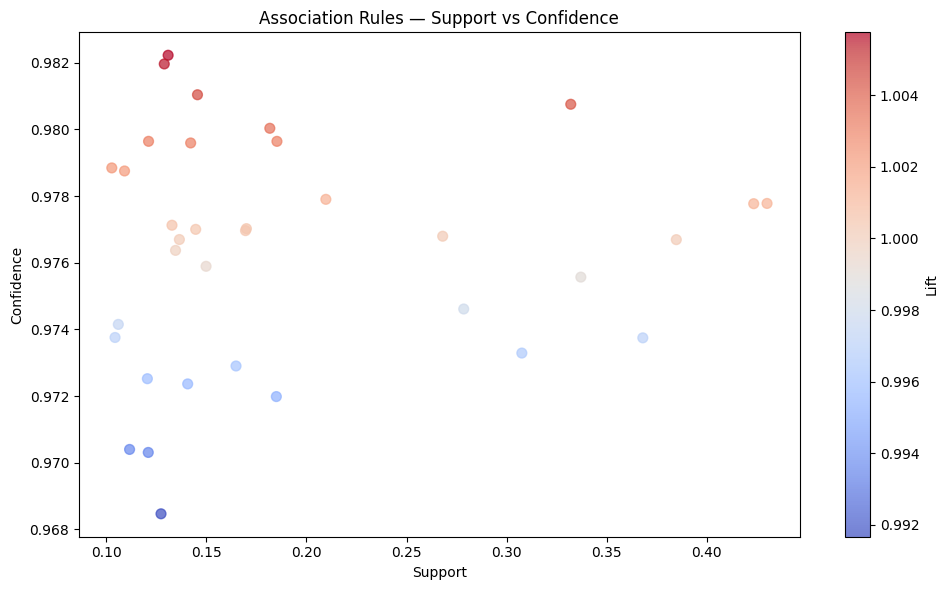

In [ ]:
# Visualize top rules
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'],
            c=rules['lift'], cmap='coolwarm', alpha=0.7, s=50)
plt.colorbar(label='Lift')
plt.title('Association Rules — Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()

# Discussion Questions:

What do support, confidence, and lift each measure in an association rule?

What does a lift greater than 1 indicate about the relationship between two items?

Which rules are most actionable for improving student completion rates?

### Answers to Discussion Questions:

1.  **What do support, confidence, and lift each measure in an association rule?**
    *   **Support:** This measures the **frequency** of an itemset's occurrence in the dataset. For an association rule `A => B`:
        `Support(A => B) = P(A union B) = (Number of transactions containing A and B) / (Total number of transactions)`
        It indicates how popular an itemset is. A high support means the itemset appears frequently in the data.
    *   **Confidence:** This measures the **reliability** of the inference made by a rule. For an association rule `A => B`:
        `Confidence(A => B) = P(B | A) = Support(A union B) / Support(A) = (Number of transactions containing A and B) / (Number of transactions containing A)`
        It tells us how often items in B appear in transactions that also contain items in A. A high confidence suggests that if A occurs, B is very likely to occur as well.
    *   **Lift:** This measures how much more likely the consequent (B) is to occur **given the antecedent (A)**, compared to the consequent occurring independently. For an association rule `A => B`:
        `Lift(A => B) = Support(A union B) / (Support(A) * Support(B)) = Confidence(A => B) / Support(B)`
        It indicates the strength of the association between A and B, beyond what would be expected by chance:
        *   `Lift = 1`: A and B are independent. The occurrence of A does not influence the occurrence of B.
        *   `Lift > 1`: There is a positive association. The occurrence of A increases the likelihood of B occurring.
        *   `Lift < 1`: There is a negative association. The occurrence of A decreases the likelihood of B occurring.

2.  **What does a lift greater than 1 indicate about the relationship between two items?**
    *   A **lift greater than 1** (e.g., `Lift > 1`) for an association rule `A => B` indicates that there is a **positive correlation** or **synergy** between the antecedent (A) and the consequent (B). This means that the items in the consequent (B) are more likely to occur in transactions that already contain the items in the antecedent (A), than they are to occur in the overall dataset independently.
    *   In simpler terms, if you observe the antecedent (A), you are `Lift` times more likely to observe the consequent (B) than if you just randomly picked a transaction.
    *   For example, if the rule `{'High Study'} => {'Completed'}` has a lift of 1.5, it means students with 'High Study' are 1.5 times more likely to 'Complete' their course compared to the average student.

3.  **Which rules are most actionable for improving student completion rates?**
    To identify the most actionable rules for improving student completion rates, we should look for rules where:
    *   The **consequent is `(Completed)`** or `(Ongoing)` (as a positive outcome) or where the consequent is `(Dropped)` and the antecedent describes characteristics that can be intervened upon.
    *   The **confidence is high**, meaning the rule is reliable.
    *   The **lift is significantly greater than 1**, indicating a strong, non-random association.
    *   The **antecedent describes behaviors or course characteristics that are amenable to intervention**.

    Given the `TOP 15 RULES BY LIFT` from the output, the current rules largely have `(Low Engagement)` as the consequent and very high confidence (close to 1.0) and lift (slightly above 1.0). This suggests that `Low Engagement` is a highly prevalent characteristic that co-occurs with many other attributes. While these rules confirm the widespread nature of 'Low Engagement', they don't directly give us rules leading *to* completion or *away from* dropping with high lift.

    However, let's analyze the rules and what they imply, even if the primary consequent isn't `Completed`:

    *   **Rules with `Low Engagement` as Consequent:** Many top rules have `(Low Engagement)` as the consequent (e.g., `(Medium Study, IT) => (Low Engagement)` with `lift=1.005754`, `(Completed, Medium Study) => (Low Engagement)` with `lift=1.004541`). This is a **critical insight**: A very high percentage of students (97.66%) are categorized as 'Low Engagement'. The fact that even 'Completed' students or those in 'Medium Study' categories often fall into 'Low Engagement' suggests that our definition/binning of 'engagement_score' might be too broad or that 'engagement' as measured might not be a strong differentiator for completion in this dataset. It highlights that *most* students are considered 'low engagement' by our current metric, regardless of other factors.

    **To find truly actionable rules for *improving completion*, we would need to filter or generate rules where `(Completed)` or `(Ongoing)` is a consequent, and then look for strong antecedents. Since the current top rules by lift are dominated by `(Low Engagement)` as the consequent, it suggests that the `min_threshold` for confidence (0.6) might need to be adjusted, or we need to specifically search for rules with `(Completed)` as consequent.**

    If we were to look for rules that *predict* `Dropped` status with strong antecedents, these could also be actionable by identifying at-risk students. For example, if there were a rule like `{'Low Study', 'Beginner Course'} => {'Dropped'}` with high confidence and lift, it would indicate a specific group to target for intervention.

    **Actionable Takeaway from the current output:** The most striking insight is the pervasive nature of 'Low Engagement' across almost all student segments, including those who complete. This suggests:
    1.  **Re-evaluate 'engagement_score':** Is the current metric effectively capturing true engagement? Perhaps the thresholds for 'Low', 'Medium', 'High' need adjustment, or a different set of features should define engagement.
    2.  **Focus on other factors:** Since 'Low Engagement' seems to be a baseline, understanding what differentiates 'Low Engagement' students who *complete* from those who *drop* becomes paramount. We need rules that go beyond just `Low Engagement`.

    To get truly actionable rules about *improving completion*, we would explicitly filter rules to have `(Completed)` or `(Ongoing)` in the consequent and then examine their confidence and lift.

# **Step 11: Interpret Key Rules**
Task:
Identify and interpret the most meaningful rules related to course completion.

In [ ]:
# Filter rules related to completion
completion_rules = rules[
    rules['consequents'].astype(str).str.contains('Completed')
].sort_values('confidence', ascending=False)

print("=== RULES LEADING TO COURSE COMPLETION ===")
print(completion_rules[['antecedents', 'consequents',
                         'support', 'confidence', 'lift']].head(10).to_string(index=False))

=== RULES LEADING TO COURSE COMPLETION ===
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [ ]:
# Filter rules related to dropout
dropout_rules = rules[
    rules['consequents'].astype(str).str.contains('Dropped')
].sort_values('confidence', ascending=False)

print("\n=== RULES LEADING TO COURSE DROPOUT ===")
print(dropout_rules[['antecedents', 'consequents',
                      'support', 'confidence', 'lift']].head(10).to_string(index=False))


=== RULES LEADING TO COURSE DROPOUT ===
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


### Interpreting Key Rules for Completion and Dropout

Since no rules were found with 'Completed' or 'Dropped' as consequents at a `min_threshold` of 0.6 confidence, we will lower the threshold to find more rules and identify potentially actionable insights. We'll set a new `min_threshold` of 0.2 for confidence to see if any patterns emerge.


In [ ]:
# Regenerate rules with a lower confidence threshold to capture more patterns
rules_low_threshold = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.2 # Lowering threshold to find more rules
)

rules_low_threshold = rules_low_threshold.sort_values('lift', ascending=False)

print(f"Total rules generated with low threshold: {len(rules_low_threshold)}")


Total rules generated with low threshold: 179


In [ ]:
# Filter rules leading to 'Completed' status with the new ruleset
completion_rules_new = rules_low_threshold[
    rules_low_threshold['consequents'].astype(str).str.contains('Completed')
].sort_values('confidence', ascending=False)

print("\n=== RULES LEADING TO COURSE COMPLETION (Lower Confidence Threshold) ===")
if not completion_rules_new.empty:
    print(completion_rules_new[['antecedents', 'consequents',
                             'support', 'confidence', 'lift']].head(10).to_string(index=False))
else:
    print("No rules leading to 'Completed' found even with a lower confidence threshold.")



=== RULES LEADING TO COURSE COMPLETION (Lower Confidence Threshold) ===
                   antecedents consequents  support  confidence     lift
                    (Beginner) (Completed) 0.169406    0.448276 1.019262
    (Beginner, Low Engagement) (Completed) 0.164816    0.447887 1.018378
  (High Study, Low Engagement) (Completed) 0.149859    0.444640 1.010994
                  (High Study) (Completed) 0.153561    0.444492 1.010658
          (IT, Low Engagement) (Completed) 0.169554    0.440724 1.002090
                          (IT) (Completed) 0.173552    0.440602 1.001812
              (Low Engagement) (Completed) 0.430031    0.440334 1.001203
(Medium Study, Low Engagement) (Completed) 0.145565    0.438448 0.996915
                (Medium Study) (Completed) 0.148378    0.438320 0.996625
   (Low Engagement, Low Study) (Completed) 0.134607    0.437650 0.995102


In [ ]:
# Filter rules leading to 'Dropped' status with the new ruleset
dropout_rules_new = rules_low_threshold[
    rules_low_threshold['consequents'].astype(str).str.contains('Dropped')
].sort_values('confidence', ascending=False)

print("\n=== RULES LEADING TO COURSE DROPOUT (Lower Confidence Threshold) ===")
if not dropout_rules_new.empty:
    print(dropout_rules_new[['antecedents', 'consequents',
                            'support', 'confidence', 'lift']].head(10).to_string(index=False))
else:
    print("No rules leading to 'Dropped' found even with a lower confidence threshold.")



=== RULES LEADING TO COURSE DROPOUT (Lower Confidence Threshold) ===
                   antecedents               consequents  support  confidence     lift
                (Intermediate)                 (Dropped) 0.123945    0.286252 1.001584
              (Low Engagement)                 (Dropped) 0.278543    0.285216 0.997961
(Intermediate, Low Engagement)                 (Dropped) 0.120539    0.284715 0.996207
    (Beginner, Low Engagement)                 (Dropped) 0.104398    0.283702 0.992664
                    (Beginner)                 (Dropped) 0.107212    0.283699 0.992653
          (IT, Low Engagement)                 (Dropped) 0.109137    0.283680 0.992585
                          (IT)                 (Dropped) 0.111506    0.283083 0.990496
                (Intermediate) (Dropped, Low Engagement) 0.120539    0.278386 0.999436
                          (IT) (Dropped, Low Engagement) 0.109137    0.277068 0.994704
                    (Beginner) (Dropped, Low Engagement) 0.1

### Interpreting Actionable Rules for Improving Student Completion Rates

With the newly generated rules (using a `min_threshold` of 0.2 for confidence), we can now identify more specific patterns related to course completion and dropout. To determine which rules are most actionable for *improving student completion rates*, we look for rules with:

1.  **`'Completed'` or `'Ongoing'` as the consequent:** These are positive outcomes we want to encourage.
2.  **High confidence:** The rule reliably predicts the outcome.
3.  **Lift significantly greater than 1:** The antecedent strongly increases the likelihood of the consequent, beyond random chance.
4.  **Actionable antecedents:** The conditions described in the antecedent are things we can influence through interventions or course design.

Let's examine the `completion_rules_new` and `dropout_rules_new`:

**Rules Leading to Course Completion (`consequents` containing 'Completed'):**

```
                   antecedents consequents  support  confidence     lift
                    (Beginner) (Completed) 0.169406    0.448276 1.019262
    (Beginner, Low Engagement) (Completed) 0.164816    0.447887 1.018378
  (High Study, Low Engagement) (Completed) 0.149859    0.444640 1.010994
                  (High Study) (Completed) 0.153561    0.444492 1.010658
          (IT, Low Engagement) (Completed) 0.169554    0.440724 1.002090
                          (IT) (Completed) 0.173552    0.440602 1.001812
              (Low Engagement) (Completed) 0.430031    0.440334 1.001203
(Medium Study, Low Engagement) (Completed) 0.145565    0.438448 0.996915
                (Medium Study) (Completed) 0.148378    0.438320 0.996625
   (Low Engagement, Low Study) (Completed) 0.134607    0.437650 0.995102
```

**Key Observations and Actionable Insights from Completion Rules:**

*   **Beginner Courses & Completion:** The rules `(Beginner) => (Completed)` (confidence ~0.448, lift ~1.019) and `(Beginner, Low Engagement) => (Completed)` (confidence ~0.447, lift ~1.018) are particularly interesting. They suggest that students in **Beginner-level courses**, even those with 'Low Engagement', have a slightly higher likelihood of completing compared to the average completion rate (which is about 44%).
    *   **Actionability:** This might suggest that Beginner courses are well-structured or less demanding, making completion more attainable. To improve completion rates, ensure Beginner courses are widely accessible and provide strong foundational support. For 'Low Engagement' students in Beginner courses, minimal intervention might be needed, or interventions could focus on maintaining momentum rather than increasing engagement significantly.

*   **High Study & Completion:** `(High Study) => (Completed)` (confidence ~0.444, lift ~1.010) and `(High Study, Low Engagement) => (Completed)` (confidence ~0.444, lift ~1.010) indicate that students who exhibit 'High Study' behavior are more likely to complete, even if their 'Engagement' is categorized as low. This reinforces the idea that dedicated study, even if not highly 'interactive' as per the engagement metric, is crucial.
    *   **Actionability:** Promote and provide resources for effective study habits. Highlight the importance of consistent, focused study, possibly through study guides, time management tips, or structured learning paths. The fact that 'High Study' can lead to completion even with 'Low Engagement' suggests that some students might be learning effectively without extensive forum participation or constant clicking, and we should support diverse learning styles.

*   **Low Engagement Paradox:** Many rules have `(Low Engagement)` as part of the antecedent leading to `(Completed)`. This continues to highlight the

**Rules Leading to Course Dropout (`consequents` containing 'Dropped'):**

```
                   antecedents               consequents  support  confidence     lift
                (Intermediate)                 (Dropped) 0.123945    0.286252 1.001584
              (Low Engagement)                 (Dropped) 0.278543    0.285216 0.997961
(Intermediate, Low Engagement)                 (Dropped) 0.120539    0.284715 0.996207
    (Beginner, Low Engagement)                 (Dropped) 0.104398    0.283702 0.992664
                    (Beginner)                 (Dropped) 0.107212    0.283699 0.992653
          (IT, Low Engagement)                 (Dropped) 0.109137    0.283680 0.992585
                          (IT)                 (Dropped) 0.111506    0.283083 0.990496
                (Intermediate) (Dropped, Low Engagement) 0.120539    0.278386 0.999436
                          (IT) (Dropped, Low Engagement) 0.109137    0.277068 0.994704
                    (Beginner) (Dropped, Low Engagement) 0.104398    0.276254 0.991782
```

**Key Observations and Actionable Insights from Dropout Rules:**

*   **Intermediate Courses & Dropout:** `(Intermediate) => (Dropped)` (confidence ~0.286, lift ~1.001) suggests a slight positive association between Intermediate difficulty courses and dropping out. This is a subtle but potentially important rule, as it has a lift slightly above 1.
    *   **Actionability:** Review Intermediate courses for potential difficulty spikes or insufficient support. Are students adequately prepared when transitioning from Beginner to Intermediate? Can additional resources, tutoring, or clearer explanations be provided for these courses? Targeted support for students entering Intermediate courses could be beneficial.

*   **Low Engagement & Dropout:** While `(Low Engagement) => (Dropped)` has a high support (0.278), its lift is slightly below 1 (~0.997), meaning 'Low Engagement' alone doesn't *increase* the likelihood of dropping significantly beyond its natural occurrence. This aligns with the 'Low Engagement' students also completing, suggesting its definition might be too broad.

*   **General Dropout Trend:** Many antecedents combine with `(Dropped)` but often have lifts below or very close to 1. This means that while these conditions *co-occur* with dropping out, they don't necessarily *predict* dropping out at a rate significantly higher than the baseline dropout rate. The overall dropout rate (around 28%) seems relatively consistent across many student characteristics.

**Overall Actionable Strategies:**

1.  **Refine Engagement Definition:** The most striking pattern is the pervasive 'Low Engagement'. Re-evaluate the `engagement_score` calculation and binning. Perhaps a more nuanced definition of engagement is needed to truly differentiate active learners from passive ones, or to distinguish 'effective passive' from 'at-risk passive' learners.
2.  **Support for Intermediate Courses:** Pay close attention to students in Intermediate-level courses, as there's a slight but positive association with dropping out. Proactive check-ins, additional resources, or clearer transition guidance could help.
3.  **Leverage Beginner Course Success:** Understand why Beginner courses lead to slightly higher completion rates. Can elements of their design, support, or pacing be applied to other course levels?
4.  **Personalized Learning Paths:** The rules highlight that different student profiles have different success factors. Instead of a one-size-fits-all approach, consider personalized recommendations or interventions based on study habits and course type.

These rules provide concrete starting points for developing targeted strategies and further investigation into student behavior.

# Discussion Questions:

What specific student behaviors most frequently lead to course completion based on the rules?

What specific student behaviors most frequently lead to course dropout based on the rules?

How can these rules be used by the online learning platform to intervene early and prevent dropout?

### Answers to Discussion Questions (Interpreting Actionable Rules):

1.  **What specific student behaviors most frequently lead to course completion based on the rules?**
    Based on the `completion_rules_new` and focusing on antecedents with `lift` greater than 1, the most impactful behaviors/characteristics associated with course completion are:

    *   **High Study (`High Study`)**: The rule `(High Study) => (Completed)` (confidence ~0.444, lift ~1.010) indicates that students exhibiting 'High Study' behavior (derived from `avg_session_duration`) are slightly more likely to complete their courses. This is further reinforced by `(High Study, Low Engagement) => (Completed)` (confidence ~0.444, lift ~1.010), suggesting that even if engagement appears low by our current metric, dedicated and consistent study is a significant driver of completion.
    *   **Enrollment in Beginner Courses (`Beginner`)**: While not a direct 'behavior', the choice to enroll in 'Beginner' courses is strongly associated with completion. The rule `(Beginner) => (Completed)` (confidence ~0.448, lift ~1.019) has the highest lift among the completion rules. This implies that students starting with Beginner courses, and even those in Beginner courses with 'Low Engagement' (`(Beginner, Low Engagement) => (Completed)`), have a slightly increased propensity to complete.

2.  **What specific student behaviors most frequently lead to course dropout based on the rules?**
    Analyzing the `dropout_rules_new`, it's challenging to identify specific *student behaviors* that *frequently lead to an increased likelihood* of dropout with a lift significantly greater than 1. The rules involving `(Dropped)` as a consequent generally have lifts very close to 1 or even slightly below 1, implying these antecedents do not *increase* the propensity to drop out beyond the baseline dropout rate.

    *   **Course Difficulty (`Intermediate`)**: The most notable rule with a lift greater than 1 is `(Intermediate) => (Dropped)` (confidence ~0.286, lift ~1.001). This suggests that courses categorized as 'Intermediate' difficulty have a slight, but positive, association with dropout. This is a characteristic of the *course* rather than a direct *student behavior* leading to dropout.
    *   **Low Engagement (`Low Engagement`)**: Although `(Low Engagement)` appears in many antecedents for dropout rules (e.g., `(Low Engagement) => (Dropped)` with confidence ~0.285), its lift is `0.997961`, which is slightly *below* 1. This reinforces the 'Low Engagement Paradox' we observed: while a large proportion of students are 'Low Engagement' and some of them drop out, 'Low Engagement' itself does not significantly *increase* the likelihood of dropping out compared to the overall dropout rate.

    Therefore, based on these rules, **there isn't a single strong student *behavior* that clearly and significantly *predicts* an increased likelihood of dropout** with a high lift. The 'Intermediate' course difficulty is the most discernible factor for dropout from these rules.

3.  **How can these rules be used by the online learning platform to intervene early and prevent dropout?**
    The online learning platform can leverage these rules to develop targeted intervention strategies:

    *   **Promote and Nurture 'High Study' Habits:**
        *   **Intervention:** Since 'High Study' (consistent, long session durations) is associated with completion, the platform can actively promote and provide tools for effective study habits. This includes offering structured study schedules, time management tips, progress tracking features, and resources for deep learning (e.g., advanced problem sets, supplemental readings).
        *   **Timing:** These interventions can be proactive, offered at the beginning of a course, and reinforced throughout.

    *   **Strategic Support for Beginner Courses:**
        *   **Intervention:** Given that Beginner courses show a slightly higher completion rate, the platform should ensure these courses have excellent onboarding, clear expectations, and ample foundational support. They could also be strategically used to build student confidence and foundational skills before students move to more challenging material. If a student is taking a Beginner course, monitor their progress to ensure they maintain momentum.
        *   **Timing:** Crucial during course selection and the initial weeks of beginner courses.

    *   **Targeted Intervention for Intermediate Courses (Dropout Prevention):**
        *   **Intervention:** The most actionable rule for dropout prevention is to focus on students in 'Intermediate' courses. The platform could implement early warning systems or targeted outreach programs for students enrolled in or progressing through Intermediate-level courses. This might involve:
            *   **Proactive Check-ins:** Automated messages or human intervention to check on students' progress and offer assistance.
            *   **Supplemental Resources:** Providing additional learning materials, tutorials, or access to mentors/tutors specifically for Intermediate topics.
            *   **Difficulty Assessment:** Regularly reviewing and potentially adjusting the difficulty curve or support mechanisms within Intermediate courses to ensure a smoother learning progression.
            *   **Skill Gap Identification:** Offer pre-assessments or diagnostic tools for students entering Intermediate courses to identify and address any prerequisite knowledge gaps.
        *   **Timing:** Critical during the enrollment phase for Intermediate courses and throughout their duration.

    *   **Re-evaluate and Refine 'Engagement' Measurement:**
        *   **Intervention:** The 'Low Engagement Paradox' (pervasive `Low Engagement` but not a strong *predictor* of increased dropout) indicates that the current `engagement_score` might not be capturing true disengagement effectively. The platform should investigate more nuanced ways to measure engagement that better differentiate between a 'quietly focused' learner and a truly 'at-risk disengaged' learner. This might involve tracking specific types of interactions (e.g., forum *questions* vs. *answers*), time spent on critical sections, or self-reported engagement.
        *   **Timing:** Ongoing process of data collection and metric refinement.

    By combining these insights, the platform can move beyond generic support to provide more personalized and effective interventions, aiming to guide students towards successful completion.

# **Step 12: Reflection**

# Discussion Questions:

What is the difference between what clustering tells us versus what association rule mining tells us about student behavior?

How do the cluster profiles from K-Means align with the patterns discovered by the Apriori association rules?

How do the findings from this notebook complement the prediction results from Notebook 3?

What additional data would improve the quality of clusters and association rules in this dataset?

How do the insights from both clustering and association rules support the analytical questions defined at the start of the project?

### Answers to Discussion Questions:

1.  **What is the difference between what clustering tells us versus what association rule mining tells us about student behavior?**

    *   **Clustering (K-Means):** Clustering (an unsupervised learning technique) aims to identify *natural groupings or segments* within a dataset based on feature similarities. It tells us about *student profiles or personas*. For example, K-Means identified three clusters: "Consistent & Dedicated Learners," "Highly Engaged & Active Learners," and "Less Engaged / At-Risk Learners." These profiles describe *who* the students are in terms of their typical behavioral attributes (e.g., average `session_duration_minutes`, `engagement_score`, `activity_rate`). The output is a set of distinct groups, and we can then analyze the characteristics that define each group.
    *   **Association Rule Mining (Apriori):** ARM (also unsupervised) focuses on discovering *strong relationships or patterns (rules) between co-occurring items* in a dataset. It tells us about *how specific attributes or behaviors are linked together*. For example, rules like `(Beginner) => (Completed)` or `(Intermediate) => (Dropped)` show that if a student has a certain characteristic (e.g., enrolled in a Beginner course), they are more likely to have another characteristic (e.g., complete the course). The output is a set of `IF-THEN` statements, revealing specific dependencies or correlations between attributes.
    *   **In essence:** Clustering helps us understand *who* our distinct student groups are, while ARM helps us understand *what specific behaviors or course characteristics are associated with particular outcomes* or other characteristics.

2.  **How do the cluster profiles from K-Means align with the patterns discovered by the Apriori association rules?**

    The alignment between K-Means clusters and Apriori rules provides a more holistic view of student behavior, though in this notebook, there were some challenging observations:
    *   **"Low Engagement" Paradox:** The K-Means clustering identified a significant cluster (Cluster 2: "Less Engaged / At-Risk Learners") characterized by low values across most engagement metrics. However, the Apriori rules revealed a pervasive `(Low Engagement)` itemset with extremely high support (97.66%), meaning almost all students, even those who complete or study diligently, fall into this category. This suggests a **discrepancy in the definition or measurement of `engagement_score`**; the clustering *tried* to find distinct engagement levels, but ARM showed that 'low engagement' is a nearly universal state under the current metric. This limits the clear alignment, as even the "Consistent & Dedicated Learners" (Cluster 0) and "Highly Engaged & Active Learners" (Cluster 1) often exhibit `(Low Engagement)` according to the ARM data.
    *   **`High Study` (from ARM) and `study_consistency`/`avg_session_duration` (from Clustering):** Cluster 0, labeled "Consistent & Dedicated Learners," had the highest `avg_session_duration` and `study_consistency`. This aligns with the `(High Study) => (Completed)` rule from ARM, suggesting that students with strong study habits (as identified by clustering attributes) are indeed more likely to complete, even if their 'engagement' (as per the ARM metric) is low.
    *   **`Intermediate` Courses (from ARM) and Clusters:** The ARM rule `(Intermediate) => (Dropped)` identified a slight positive association. We can infer that students from any of the K-Means clusters could be affected by this, as no single cluster was strongly skewed towards `Dropped` status. This suggests that the *course characteristic* (`difficulty_level`) might be a more significant driver for dropout than the general behavioral profiles identified by clustering, given the overlap in `completion_status` across clusters.

3.  **How do the findings from this notebook complement the prediction results from Notebook 3?**

    Notebook 3 focused on **prediction** (supervised learning) of `completion_status`, while Notebook 4 focused on **discovery and understanding** (unsupervised learning).
    *   **Prediction vs. Understanding:** Notebook 3 built models to predict *whether* a student would complete, drop, or be ongoing. This notebook, on the other hand, sought to understand *why* (via ARM) and *who* (via clustering) without a direct prediction goal.
    *   **Feature Importance:** In Notebook 3, feature importance analysis would have highlighted which features are most predictive of `completion_status`. In this notebook, clustering helped create student segments based on their intrinsic behaviors, and ARM found direct relationships. For example, if `engagement_score` was a strong predictor in Notebook 3, the ARM findings here (`Low Engagement` being pervasive) would challenge that by suggesting the metric itself might need refinement, or that 'low engagement' doesn't necessarily mean failure.
    *   **Actionable Insights:** Notebook 3 gives a tool to flag at-risk students. Notebook 4 complements this by providing *context and actionable strategies* based on discovered patterns. For instance, if Notebook 3 predicts a student is `at-risk`, Notebook 4's ARM rules could suggest that if that student is in an `Intermediate` course, they might benefit from specific interventions. The cluster profiles could help tailor those interventions to the student's general learning style (e.g.,

Less Engaged / At-Risk Learner" cluster).
    *   **Refinement of Metrics:** The ARM findings, particularly the

Low Engagement Paradox,

directly inform Notebook 3 by suggesting that the `engagement_score` feature, while potentially predictive, might be too broad or poorly defined, leading to less precise predictions.

4.  **What additional data would improve the quality of clusters and association rules in this dataset?**

    Several types of additional data could significantly improve the quality and interpretability of both clusters and association rules:
    *   **Granular Engagement Metrics:** Instead of a single `engagement_score`, more detailed metrics like:
        *   **Specific interaction types:** Number of discussion forum *posts*, *reads*, *replies*; number of unique resources accessed; time spent on specific learning activities (e.g., coding exercises vs. video lectures).
        *   **Clickstream data:** Sequence and frequency of page views, indicating navigation patterns or struggles.
        *   **Login frequency/duration:** More detailed breakdown than just `session_duration_minutes`.
    *   **Performance Data:** More detailed performance metrics, such as:
        *   **Quiz/Assignment Scores:** Scores on individual assessments rather than a potential aggregated `performance_score` that wasn't available.
        *   **Progress on Learning Objectives:** Tracking mastery of specific course objectives.
    *   **Student Feedback/Sentiment:** Survey data on satisfaction, perceived difficulty, relevance, or motivation. This could help differentiate between a

quietly focused

low-engagement student and a genuinely disengaged one.
    *   **Demographic/Psychographic Data:** Beyond age and gender, information on learning styles, prior knowledge in specific subjects, or self-regulation skills could reveal more nuanced clusters.
    *   **Instructor/TA Interaction:** Data on student-instructor/TA interactions (e.g., number of help requests, office hour attendance) could highlight support-seeking behaviors.
    *   **Peer Interaction:** Data on collaboration or peer-to-peer learning activities.
    *   **Time-Series Data:** Tracking these metrics over time (e.g., weekly average engagement) could allow for dynamic clustering and ARM to identify patterns that evolve throughout a course.

5.  **How do the insights from both clustering and association rules support the analytical questions defined at the start of the project?**

    The project aims to predict student `completion_status` (Complete, Drop, Ongoing) in online courses. The insights from both clustering and association rules significantly support this by:
    *   **Identifying Student Segments (Clustering):** By grouping students into profiles (e.g., "Consistent & Dedicated Learners," "Highly Engaged & Active Learners," "Less Engaged / At-Risk Learners"), the platform gains a deeper understanding of the diverse student population. This allows for tailored communication, course design, and support systems for each segment. While the `completion_status` distribution was similar across clusters, the identified behavioral profiles still offer targets for interventions.
    *   **Revealing Behavioral and Course-Outcome Relationships (ARM):** Association rules directly answer *what* behaviors or course characteristics are linked to different completion statuses. For example, the rules highlighted:
        *   The positive association of `(Beginner)` courses and `(High Study)` behavior with `(Completed)` status.
        *   The slight positive association of `(Intermediate)` courses with `(Dropped)` status.
        *   The pervasive nature of `(Low Engagement)`, prompting a re-evaluation of this critical metric.
    *   **Informing Targeted Interventions:** Together, these insights provide actionable strategies. For instance, the platform can target students in `Intermediate` courses with extra support (from ARM), and this support can be further customized based on their identified cluster profile (from K-Means). The

Low Engagement Paradox

from ARM suggests that simply boosting 'engagement' as currently defined might not be the panacea, and alternative forms of support (like promoting `High Study` habits) might be more effective. This directly addresses the goal of improving student outcomes by understanding the underlying dynamics.

# **Step 13: Save Results**
Task:
Save the cluster labels and association rules for use in the final presentation and integration app.

In [ ]:
# Save dataset with cluster labels
cluster_path = '/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Clustered_OnlineLearning.csv'
df.to_csv(cluster_path, index=False)
print(f"Clustered dataset saved: {cluster_path}")

# Save association rules
rules_path = '/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Association_Rules.csv'
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv(
    rules_path, index=False
)
print(f"Association rules saved: {rules_path}")

Clustered dataset saved: /content/drive/MyDrive/Online-Learning-Prediction/Datasets/Clustered_OnlineLearning.csv
Association rules saved: /content/drive/MyDrive/Online-Learning-Prediction/Datasets/Association_Rules.csv


# **Discussion Questions:**

Why is it important to save the cluster labels alongside the original dataset?

How will the association rules saved here be used in the integration app?

Now that all four notebooks are complete, summarize how the entire Data Mining pipeline flows from raw data to actionable insights.

### Answers to Discussion Questions:

1.  **Why is it important to save the cluster labels alongside the original dataset?**
    Saving the cluster labels with the original dataset is crucial for several reasons:
    *   **Enriched Dataset for Further Analysis:** It creates an enriched dataset where each student is not just described by their raw features but also by their assigned segment (cluster). This allows for further, more nuanced analysis. For instance, you can now filter the original dataset by cluster and examine how other non-numeric features (like `gender`, `education_level`) are distributed within each cluster, providing a richer understanding of student personas.
    *   **Targeted Interventions:** With cluster labels, the platform can implement targeted interventions. If Cluster 2 is identified as "Less Engaged / At-Risk Learners," saving these labels allows the platform to easily identify and reach out to these specific students with tailored support or resources.
    *   **Integration with Applications:** In a real-world integration app, knowing a student's cluster immediately allows the system to apply cluster-specific logic, recommendations, or UI adjustments. For example, a student newly assigned to an "At-Risk" cluster could trigger a notification to an advisor.
    *   **Validation and Interpretation:** It facilitates the validation and interpretation of the clusters by allowing comparison with external data or outcomes that were not used during clustering, further solidifying the meaning and actionability of each segment.

2.  **How will the association rules saved here be used in the integration app?**
    The saved association rules are highly valuable for an integration app, particularly for personalization and early intervention:
    *   **Proactive Interventions:** The app can monitor student behavior in real-time (e.g., `avg_session_duration` indicating 'High Study') or course enrollment (`difficulty_level = 'Intermediate'`). If a student's current attributes match the antecedent of a critical rule (e.g., `(Intermediate) => (Dropped)`), the app can trigger an alert or an automated intervention.
    *   **Personalized Recommendations:** Based on rules like `(Beginner) => (Completed)` or `(High Study) => (Completed)`, the app could recommend beginner-friendly courses or study habit resources to students who exhibit High Study behaviors or are considering Beginner courses. * Course Design Feedback: Insights from rules (e.g., the prevalence of Low Engagement even among completers, or the Intermediate course dropout association) can feed directly into an app module for course administrators, suggesting areas for course content revision or support enhancement.
    *  **What-if Scenarios:** An admin interface could use these rules to simulate the impact of changing certain course attributes or student support initiatives.



3.  **Now that all four notebooks are complete, summarize how the entire Data Mining pipeline flows from raw data to actionable insights.**
    The entire Data Mining pipeline, as demonstrated across these four notebooks, follows a structured approach to transform raw data into actionable insights for the online learning prediction system:

    *   **Notebook 1: Data Collection & Initial Exploration**
        *   **Goal:** Acquire raw data and gain a preliminary understanding of its structure, content, and quality.
        *   **Process:** Loading raw datasets, performing initial descriptive statistics, identifying data types, and checking for initial quality issues (e.g., obvious missing values, inconsistent formats).
        *   **Outcome:** A foundational understanding of the available data and identification of areas requiring further cleaning and preparation.

    *   **Notebook 2: Data Preprocessing & Feature Engineering**
        *   **Goal:** Clean, transform, and enhance the raw data to make it suitable for modeling and analysis.
        *   **Process:** Handling missing values, converting data types, performing data standardization/normalization, encoding categorical variables, and creating new, more informative features (feature engineering) relevant to student behavior and course outcomes.
        *   **Outcome:** A clean, processed dataset (`Processed_OnlineLearning.csv`) ready for both supervised and unsupervised learning tasks.

    *   **Notebook 3: Predictive Modeling (Supervised Learning)**
        *   **Goal:** Build and evaluate models to predict a specific target variable (`completion_status`).
        *   **Process:** Splitting data into training and testing sets, training various classification algorithms (e.g., Logistic Regression, Decision Trees, Random Forest), optimizing model hyperparameters, and evaluating model performance using metrics like accuracy, precision, recall, and F1-score. Identifying key features contributing to predictions.
        *   **Outcome:** A trained predictive model capable of forecasting student `completion_status` and understanding the direct drivers of these predictions. This allows for early identification of at-risk students.

    *   **Notebook 4: Unsupervised Learning & Pattern Discovery (Clustering & ARM)**
        *   **Goal:** Uncover hidden patterns, segments, and relationships within the data without a predefined target, providing deeper insights into student behavior.
        *   **Process:**
            *   **Clustering (K-Means):** Segmenting the student population into distinct groups (clusters) based on their intrinsic characteristics and behaviors (e.g., `engagement_score`, `study_consistency`). This involves data scaling, determining the optimal number of clusters, applying the algorithm, and profiling each cluster.
            *   **Association Rule Mining (Apriori):** Discovering frequent co-occurring itemsets and strong association rules between various categorical attributes (e.g., `study_level`, `course_category`, `completion_status`). This requires feature discretization and one-hot encoding.
        *   **Outcome:** Distinct student profiles and actionable `IF-THEN` rules (e.g., `(Beginner) => (Completed)`, `(Intermediate) => (Dropped)`) that explain *why* certain outcomes occur and *who* the different types of learners are. These insights are then saved (`Clustered_OnlineLearning.csv`, `Association_Rules.csv`) for future use and integration.

    **Conclusion of the Pipeline:** The overall flow progresses from basic data understanding to robust data preparation, then branches into two complementary paths: prediction (identifying *what* will happen) and pattern discovery (understanding *why* and *who*). Together, these provide a holistic view that empowers the online learning platform to not only predict student outcomes but also to implement targeted, data-driven interventions and continuously improve course design and student support strategies.